Epoch   0 | val_loss: 0.132002
Epoch  20 | val_loss: 0.006366
Epoch  40 | val_loss: 0.003423
Epoch  60 | val_loss: 0.000223
Epoch  80 | val_loss: 0.000240
Epoch 100 | val_loss: 0.000241
Epoch 120 | val_loss: 0.000241
Epoch 140 | val_loss: 0.000241
Epoch 160 | val_loss: 0.000241
Epoch 180 | val_loss: 0.000241
Predicted range: 5.541863918304432 – 219.0031719505787
Training data range: 2.0 – 255.0


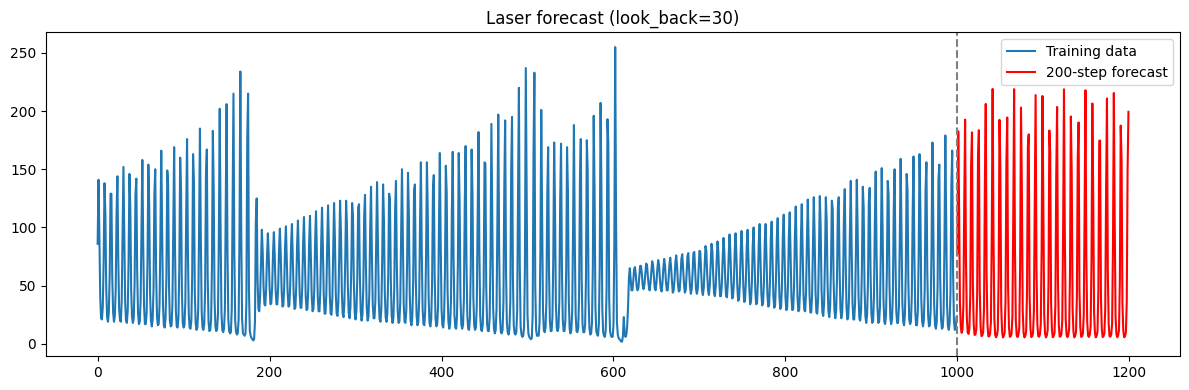

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── 1. Load & scale ──────────────────────────────────────────────────────────
data = pd.read_csv("Xtrain.csv", header=0).values.astype(float)  # (1000, 1)

scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data)          # keep scaler to invert later

# ── 2. Build sliding-window dataset ──────────────────────────────────────────
LOOK_BACK = 30   # <-- TUNE THIS (try 10, 20, 30, 50)

def make_sequences(series, look_back):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i : i + look_back])
        y.append(series[i + look_back])
    return np.array(X), np.array(y)

X, y = make_sequences(data_scaled, LOOK_BACK)
# X shape: (N, look_back, 1)  — LSTM expects (batch, seq, features)
X = X.reshape(X.shape[0], LOOK_BACK, 1)

# Train/val split (80/20, no shuffling — time series!)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=False)

# ── 3. Model ──────────────────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # only last timestep

model = LSTMForecaster(hidden_size=64, num_layers=2, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

# ── 4. Training ───────────────────────────────────────────────────────────────
EPOCHS = 200
best_val_loss = float('inf')
best_state = None

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stability
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict().copy()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | val_loss: {val_loss:.6f}")

model.load_state_dict(best_state)   # restore best checkpoint

# ── 5. Recursive 200-step forecast ───────────────────────────────────────────
model.eval()
# Seed the window with the last LOOK_BACK points of training data
window = data_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1).tolist()
window = list(np.array(window).flatten())

predictions_scaled = []
with torch.no_grad():
    for _ in range(200):
        inp = torch.FloatTensor(window[-LOOK_BACK:]).reshape(1, LOOK_BACK, 1)
        pred = model(inp).item()
        predictions_scaled.append(pred)
        window.append(pred)

# Invert scaling
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
).flatten()

print("Predicted range:", predictions.min(), "–", predictions.max())
print("Training data range:", data.min(), "–", data.max())

# ── 6. Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(range(1000), data.flatten(), label="Training data")
plt.plot(range(1000, 1200), predictions, label="200-step forecast", color="red")
plt.axvline(1000, linestyle='--', color='gray')
plt.legend()
plt.title(f"Laser forecast (look_back={LOOK_BACK})")
plt.tight_layout()
plt.savefig("forecast.png", dpi=150)
plt.show()

# ── 7. Evaluate on test set (run after May 8th) ───────────────────────────────
# Xtest = pd.read_csv("Xtest.csv", header=0).values.astype(float).flatten()
# mae = mean_absolute_error(Xtest, predictions)
# mse = mean_squared_error(Xtest, predictions)
# print(f"MAE: {mae:.4f} | MSE: {mse:.4f}")